# 🦷 DentalGemma: Validation & Inference Demo

This notebook demonstrates the capabilities of **[DentalGemma-1.5-4b-it](https://huggingface.co/naazimsnh02/dentalgemma-1.5-4b-it)**, a specialized medical VLM fine-tuned for dental diagnostics.

### 🎯 Core Capabilities validated in this notebook:
1.  **🔍 Cavity Detection**: Identifying carious lesions in bite-wing/periapical X-rays.
2.  **🏥 Pathology Classification**: Analyzing OPGs for cysts, tumors, and bone loss.
3.  **🦷 Tooth Counting**: Automating tooth charting from panoramic images.
4.  **💊 Clinical Assessment**: Generating structured treatment plans from text-based case histories.

---

## 🛠️ 1. Environment Setup

In [1]:
# Uninstall incompatible PyTorch and torchvision versions
!pip uninstall torch torchvision torchaudio

Found existing installation: torch 2.9.0+cu128
Uninstalling torch-2.9.0+cu128:
  Would remove:
    /usr/local/bin/torchfrtrace
    /usr/local/bin/torchrun
    /usr/local/lib/python3.12/dist-packages/functorch/*
    /usr/local/lib/python3.12/dist-packages/torch-2.9.0+cu128.dist-info/*
    /usr/local/lib/python3.12/dist-packages/torch/*
    /usr/local/lib/python3.12/dist-packages/torchgen/*
Proceed (Y/n)? Y
Y
  Successfully uninstalled torch-2.9.0+cu128
Found existing installation: torchvision 0.24.0+cu128
Uninstalling torchvision-0.24.0+cu128:
  Would remove:
    /usr/local/lib/python3.12/dist-packages/torchvision-0.24.0+cu128.dist-info/*
    /usr/local/lib/python3.12/dist-packages/torchvision.libs/libcudart.e8e8b82a.so.12
    /usr/local/lib/python3.12/dist-packages/torchvision.libs/libjpeg.37781fad.so.8
    /usr/local/lib/python3.12/dist-packages/torchvision.libs/libnvjpeg.8dd2b5e6.so.12
    /usr/local/lib/python3.12/dist-packages/torchvision.libs/libpng16.e328d493.so.16
    /usr/local

In [2]:
# Install compatible PyTorch and torchvision versions
!pip install torch==2.9.0+cu128 torchvision==0.24.0+cu128 --index-url https://download.pytorch.org/whl/cu128

Looking in indexes: https://download.pytorch.org/whl/cu128
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 900.9/900.9 MB 1.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.1/8.1 MB 111.6 MB/s eta 0:00:00


In [3]:
# Install other dependencies
!pip install accelerate bitsandbytes datasets evaluate peft tensorboard transformers trl huggingface_hub

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 59.1/59.1 MB 14.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 9.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 540.5/540.5 kB 43.9 MB/s eta 0:00:00


In [4]:
# HF Authentication
import os
import sys

if "google.colab" in sys.modules and not os.environ.get("VERTEX_PRODUCT"):
    from google.colab import userdata
    os.environ["HF_TOKEN"] = userdata.get("HF_TOKEN")
else:
    if os.environ.get("VERTEX_PRODUCT") == "COLAB_ENTERPRISE":
        os.environ["HF_HOME"] = "/content/hf"
    from huggingface_hub import get_token
    if get_token() is None:
        from huggingface_hub import notebook_login
        notebook_login()

In [5]:
import os
from huggingface_hub import get_token

# 1. Check if the env var is injected
if "HF_TOKEN" in os.environ:
    print("✅ Success! 'HF_TOKEN' environment variable is present.")
    print(f"Token starts with: {os.environ['HF_TOKEN'][:4]}****")
else:
    print("❌ 'HF_TOKEN' environment variable is MISSING.")

# 2. Check what Hugging Face sees
token = get_token()
if token:
    print(f"✅ Hugging Face Login Status: Authenticated (Token found)")
else:
    print("❌ Hugging Face Login Status: Not Logged In")

✅ Success! 'HF_TOKEN' environment variable is present.
Token starts with: hf_u****
✅ Hugging Face Login Status: Authenticated (Token found)


## 🤖 2. Load Model
Loading the fine-tuned adapter merged with the MedGemma 1.5 4B base model.

In [6]:
import torch
from transformers import AutoProcessor, AutoModelForImageTextToText

MODEL_ID = "naazimsnh02/dentalgemma-1.5-4b-it"

print(f"⏳ Loading model: {MODEL_ID}...")

# Check for GPU
device = "cuda" if torch.cuda.is_available() else "cpu"
dtype = torch.bfloat16 if device == "cuda" else torch.float32
print(f"Using device: {device.upper()} ({dtype})")

# Load Processor & Model
processor = AutoProcessor.from_pretrained(MODEL_ID)
model = AutoModelForImageTextToText.from_pretrained(
    MODEL_ID,
    torch_dtype=dtype,
    device_map="auto"
)

print("✅ Model loaded successfully!")

⏳ Loading model: naazimsnh02/dentalgemma-1.5-4b-it...
Using device: CUDA (torch.bfloat16)


processor_config.json:   0%|          | 0.00/580 [00:00<?, ?B/s]

chat_template.jinja:   0%|          | 0.00/1.53k [00:00<?, ?B/s]

config.json:   0%|          | 0.00/2.76k [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/743 [00:00<?, ?B/s]

...

model.safetensors:   0%|          | 0.00/9.94G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/884 [00:00<?, ?it/s]

The tied weights mapping and config for this model specifies to tie model.language_model.embed_tokens.weight to lm_head.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning


generation_config.json:   0%|          | 0.00/114 [00:00<?, ?B/s]

✅ Model loaded successfully!


In [7]:
# Helper Functions
from PIL import Image
import requests
from io import BytesIO
import time
from IPython.display import display, Markdown
import sys

def load_image(image_source):
    """Loads an image from a file path, uploaded file object, or URL."""
    # Handle uploaded file objects (from ipywidgets FileUpload)
    if hasattr(image_source, 'read'):
        return Image.open(image_source).convert("RGB")

    # Handle file paths
    if isinstance(image_source, str):
        if image_source.startswith(('http://', 'https://')):
            response = requests.get(image_source, timeout=10)
            response.raise_for_status()
            return Image.open(BytesIO(response.content)).convert("RGB")
        else:
            return Image.open(image_source).convert("RGB")

    # Handle PIL Image objects directly
    if isinstance(image_source, Image.Image):
        return image_source.convert("RGB")

    raise ValueError(f"Unsupported image source type: {type(image_source)}")

def generate_response(prompt, image=None, max_new_tokens=512):
    """Runs inference on the model with optional image input."""

    # Construct messages
    messages = [
        {"role": "system", "content": [{"type": "text", "text": "You are an expert dental clinician and radiologist AI assistant."}]},
    ]

    user_content = [{"type": "text", "text": prompt}]
    if image:
        user_content.append({"type": "image", "image": image})

    messages.append({"role": "user", "content": user_content})

    # Prepare inputs
    inputs = processor.apply_chat_template(
        messages,
        add_generation_prompt=True,
        tokenize=True,
        return_dict=True,
        return_tensors="pt"
    ).to(model.device)

    # Measure inference time
    start = time.time()
    with torch.inference_mode():
        outputs = model.generate(
            **inputs,
            max_new_tokens=max_new_tokens,
            do_sample=False  # Deterministic for validation
        )
    latency = time.time() - start

    # Decode
    generated_ids = outputs[0][inputs["input_ids"].shape[-1]:]
    response_text = processor.decode(generated_ids, skip_special_tokens=True)

    return response_text, latency

def display_result(title, prompt, response, image=None, latency=0):
    """Prettifies the output display"""
    display(Markdown(f"### {title}"))
    if image:
        # Resize for display if too large
        w, h = image.size
        aspect = h / w
        display_w = min(w, 600)
        display_h = int(display_w * aspect)
        display(image.resize((display_w, display_h)))

    display(Markdown(f"**❓ Query:** {prompt}"))
    display(Markdown(f"**🤖 Model Analysis:**\n\n{response}"))
    display(Markdown(f"*⏱️ Inference Time: {latency:.2f}s*"))
    display(Markdown("---"))

def upload_image():
    """Universal image upload function that works in Colab, Kaggle, and Modal."""

    # Detect environment
    in_colab = 'google.colab' in sys.modules
    in_kaggle = 'kaggle_secrets' in sys.modules or '/kaggle/' in os.getcwd()

    if in_colab:
        # Google Colab - use files.upload()
        from google.colab import files
        print("📤 Click 'Choose Files' to upload an image...")
        uploaded = files.upload()

        if not uploaded:
            raise ValueError("No file uploaded!")

        # Get the first uploaded file
        filename = list(uploaded.keys())[0]
        return load_image(filename)

    else:
        # Kaggle, Modal, or standard Jupyter - use ipywidgets
        try:
            from ipywidgets import FileUpload, Button, Output, VBox
            from IPython.display import display, clear_output

            # Create upload widget
            uploader = FileUpload(accept='image/*', multiple=False)
            output = Output()

            print("📤 Use the upload button below to select an image:")
            display(uploader)
            display(output)

            # Wait for upload
            import time
            timeout = 300  # 5 minutes
            start_time = time.time()

            while not uploader.value:
                time.sleep(0.5)
                if time.time() - start_time > timeout:
                    raise TimeoutError("Upload timeout - no file selected within 5 minutes")

            # Get uploaded file
            uploaded_file = list(uploader.value.values())[0]
            image = Image.open(BytesIO(uploaded_file['content'])).convert("RGB")

            with output:
                clear_output()
                print(f"✅ Uploaded: {uploaded_file['metadata']['name']}")

            return image

        except ImportError:
            # Fallback: manual file path input
            print("⚠️ ipywidgets not available. Please upload your image manually.")
            print("📁 Place your image in the notebook directory and enter the filename:")
            filename = input("Filename: ")
            return load_image(filename)

print("✅ Helper functions loaded!")


✅ Helper functions loaded!


## 🧪 3. Validation Tests

We will run 3 diverse scenarios covering the model's primary use cases.

🦷 Test 1: Cavity Detection

📸 Please upload an intraoral X-ray image
   Recommended: Bitewing or periapical radiograph

📤 Click 'Choose Files' to upload an image...


Setting `pad_token_id` to `eos_token_id`:1 for open-end generation.


Saving unhealthy_teeth_363_jpg.rf.e21d1bedde7872155f09a1aa0b4df993.jpg to unhealthy_teeth_363_jpg.rf.e21d1bedde7872155f09a1aa0b4df993 (1).jpg

🤖 Running inference...


### Cavity Detection

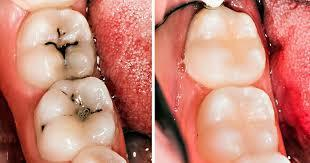

**❓ Query:** Analyze this radiograph. Count and locate any cavities present.

**🤖 Model Analysis:**

This dental X-ray shows a mix of findings: 2 cavity region(s) and 2 normal region(s). The cavities appear as dark areas suggesting decay, while other tooth structures appear intact. Clinical correlation is recommended.

*⏱️ Inference Time: 7.37s*

---

In [22]:
# Test 1: Cavity Detection (Intraoral X-Ray)

print("🦷 Test 1: Cavity Detection")
print("=" * 50)
print("\n📸 Please upload an intraoral X-ray image")
print("   Recommended: Bitewing or periapical radiograph\n")

# Upload custom image
image_1 = upload_image()

prompt_1 = "Analyze this radiograph. Count and locate any cavities present."

print("\n🤖 Running inference...")
response_1, time_1 = generate_response(prompt_1, image=image_1)

display_result("Cavity Detection", prompt_1, response_1, image_1, time_1)

🦷 Test 2: Panoramic X-ray Analysis

📸 Please upload a panoramic (OPG) X-ray image
   Recommended: Full mouth panoramic radiograph

📤 Click 'Choose Files' to upload an image...


Setting `pad_token_id` to `eos_token_id`:1 for open-end generation.


Saving 25.jpg to 25 (2).jpg

🤖 Running inference...


### Panoramic Analysis

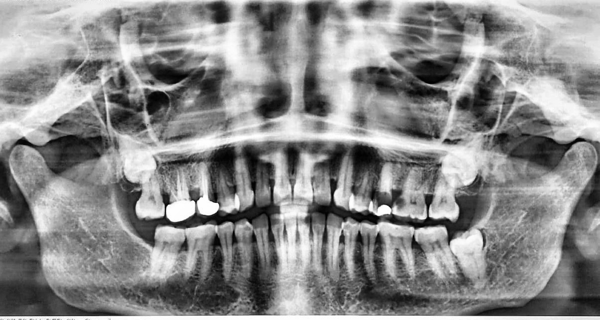

**❓ Query:** This is a panoramic dental X-ray. Identify any noticeable pathologies or abnormalities.

**🤖 Model Analysis:**

This panoramic dental X-ray shows impacted teeth - teeth that have failed to fully erupt into their expected position. This is commonly seen with third molars (wisdom teeth). A panoramic radiograph (OPG) is the primary imaging modality for diagnosing impacted teeth. The radiograph shows the angulation and proximity to adjacent structures such as the inferior alveolar nerve and adjacent teeth. Surgical intervention is required to extract the tooth under controlled conditions.

*⏱️ Inference Time: 10.75s*

---

In [24]:
# Test 2: Panoramic Pathology (OPG)

print("🦷 Test 2: Panoramic X-ray Analysis")
print("=" * 50)
print("\n📸 Please upload a panoramic (OPG) X-ray image")
print("   Recommended: Full mouth panoramic radiograph\n")

# Upload custom image
image_2 = upload_image()

prompt_2 = "This is a panoramic dental X-ray. Identify any noticeable pathologies or abnormalities."

print("\n🤖 Running inference...")
response_2, time_2 = generate_response(prompt_2, image=image_2)

display_result("Panoramic Analysis", prompt_2, response_2, image_2, time_2)

In [11]:
# Test 3: Clinical Case Study (Text Only)

print("💊 Test 3: Clinical Case Assessment")
print("=" * 50)

case_text = """
Patient: 45-year-old female
Chief Complaint: "Sharp pain when drinking cold water in the upper right back tooth."
History: Pain started 2 weeks ago, lasts for seconds. No spontaneous pain.
Clinical Findings: Tooth #16 has a defective amalgam restoration with marginal breakdown. No tenderness to percussion.
"""

print("\n📋 Case Details:")
print(case_text)

prompt_3 = f"Based on the clinical history below, provide a differential diagnosis and recommended treatment plan.\n\n{case_text}"

print("\n🤖 Running inference...")
response_3, time_3 = generate_response(prompt_3, image=None)

display_result("Clinical Case Assessment", "(See Case Text above)", response_3, None, time_3)


Setting `pad_token_id` to `eos_token_id`:1 for open-end generation.


💊 Test 3: Clinical Case Assessment

📋 Case Details:

Patient: 45-year-old female
Chief Complaint: "Sharp pain when drinking cold water in the upper right back tooth."
History: Pain started 2 weeks ago, lasts for seconds. No spontaneous pain.
Clinical Findings: Tooth #16 has a defective amalgam restoration with marginal breakdown. No tenderness to percussion.


🤖 Running inference...


### Clinical Case Assessment

**❓ Query:** (See Case Text above)

**🤖 Model Analysis:**

## Patient Assessment

**Patient:** 45-year-old female
**Chief Complaint:** "Sharp pain when drinking cold water in the upper right back tooth."
**History:** Pain started 2 weeks ago, lasts for seconds. No spontaneous pain.
**Clinical Findings:** Tooth #16 has a defective amalgam restoration with marginal breakdown. No tenderness to percussion.

## Differential Diagnosis

1.  **Defective Restoration:** The primary cause of the patient's symptoms. The amalgam is breaking down at the margin, leading to micro-tearing and sensitivity.
2.  **Dental Pulpitis:** Inflammation of the pulp tissue. Can be caused by deep restoration, caries, or trauma. Symptoms include sharp pain with stimuli (cold, touch, sweets) and sometimes spontaneous pain.
3.  **Periodontal Disease:** Bacterial infection of the gums. Can cause pain with periodontal probing and swelling.
4.  **Molar Pulpitis:** Inflammation of the pulp due to caries or trauma. Often presents with spontaneous or prolonged pain.
5.  **Defective Restoration with Pulp Involvement:** If the restoration is failing and has reached the pulp, the patient may experience more severe symptoms.

## Management Plan

1.  **Immediate:** Remove the defective restoration.
2.  **Definitive:** Place a new restoration.
    *   **Ideal:** Tooth-colored resin restoration or amalgam.
    *   **Consider:** Post-operative sensitivity management.
3.  **Monitoring:** Follow-up to ensure healing and restoration integrity.

## Patient Counseling

1.  Avoid chewing on the affected tooth until the restoration is complete.
2.  Use desensitizing toothpaste if sensitivity persists.
3.  Return immediately if pain worsens or other symptoms develop.

## Clinical Guidelines

**Source:** American Academy of Oral Medicine - Oral mucosal lesions

*⏱️ Inference Time: 30.08s*

---

## 📊 4. Performance Benchmarking
Running a quick loop to estimate average inference latency for a standard cavity detection task.

In [12]:
import numpy as np

print("🚀 Running 5 iterations for benchmarking...")
latencies = []

for i in range(5):
    _, t = generate_response(
        "Check for cavities.",
        image=image_1,
        max_new_tokens=128
    )
    latencies.append(t)
    print(f"Run {i+1}: {t:.4f}s")

avg_lat = np.mean(latencies)
print(f"\n⚡ Average Latency: {avg_lat:.4f}s")
print(f"Peak Memory: {torch.cuda.max_memory_allocated()/1024**3:.2f} GB" if torch.cuda.is_available() else "Memory: N/A")

Setting `pad_token_id` to `eos_token_id`:1 for open-end generation.


🚀 Running 5 iterations for benchmarking...


Setting `pad_token_id` to `eos_token_id`:1 for open-end generation.


Run 1: 7.7408s


Setting `pad_token_id` to `eos_token_id`:1 for open-end generation.


Run 2: 7.4169s


Setting `pad_token_id` to `eos_token_id`:1 for open-end generation.


Run 3: 7.4698s


Setting `pad_token_id` to `eos_token_id`:1 for open-end generation.


Run 4: 8.0397s
Run 5: 7.5650s

⚡ Average Latency: 7.6464s
Peak Memory: 11.66 GB
